In [1]:
!pip install xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.8 MB/s eta 0:00:00


In [2]:
import zipfile
import os

zip_file = "Temprature.zip"
extract_folder = "temperature"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Files extracted:")
print(os.listdir(extract_folder))

Files extracted:
['TMP-2m_2020050113_ncum_imdaa_reanl_2df_13.nc', 'TMP-2m_2020050213_ncum_imdaa_reanl_2df_13.nc', 'TMP-2m_2020050122_ncum_imdaa_reanl_2df_22.nc', 'TMP-2m_2020050209_ncum_imdaa_reanl_2df_09.nc', 'TMP-2m_2020050109_ncum_imdaa_reanl_2df_09.nc', 'TMP-2m_2020050222_ncum_imdaa_reanl_2df_22.nc']


In [3]:
import xarray as xr

In [4]:
ds = xr.open_dataset("temperature/TMP-2m_2020050113_ncum_imdaa_reanl_2df_13.nc")

In [5]:
lat = ds.lat.values
lon = ds.lon.values

print(lat)
print(lon)

[28.08 28.2  28.32 28.44 28.56 28.68 28.8  28.92]
[76.08 76.2  76.32 76.44 76.56 76.68 76.8  76.92 77.04 77.16 77.28 77.4
 77.52 77.64 77.76 77.88 78.  ]


In [6]:
print("Latitude Points:", len(lat))
print("Longitude Points:", len(lon))

Latitude Points: 8
Longitude Points: 17


In [7]:
print(lat[1]-lat[0])
print(lon[1]-lon[0])

0.11999999999999744
0.11999999999999034


In [8]:
lat_grid_km = (lat[1] - lat[0]) * 111

print(f"Latitude Grid Size: {lat_grid_km:.2f} km")

Latitude Grid Size: 13.32 km


In [9]:
import numpy as np

mean_lat = np.mean(lat)

lon_grid_km = (lon[1] - lon[0]) * 111 * np.cos(np.radians(mean_lat))

print(f"Longitude Grid Size: {lon_grid_km:.2f} km")

Longitude Grid Size: 11.71 km


ValueError: x and y must be the same size

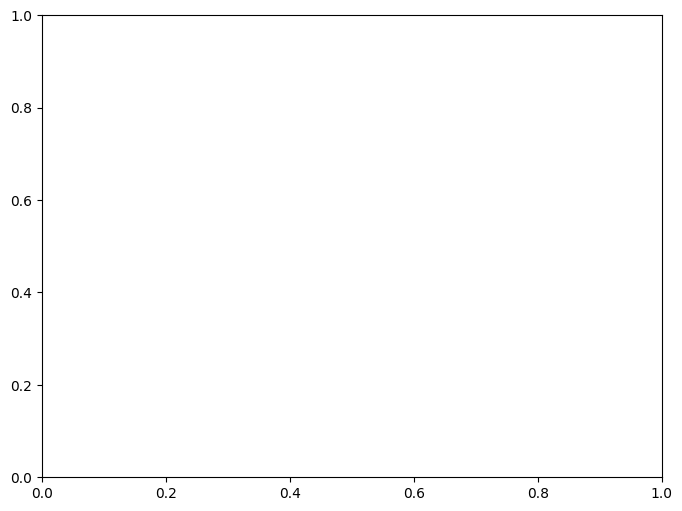

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(lon, lat, color="red", s=50)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NCMRWF Grid Points")

plt.grid(True)

plt.show()

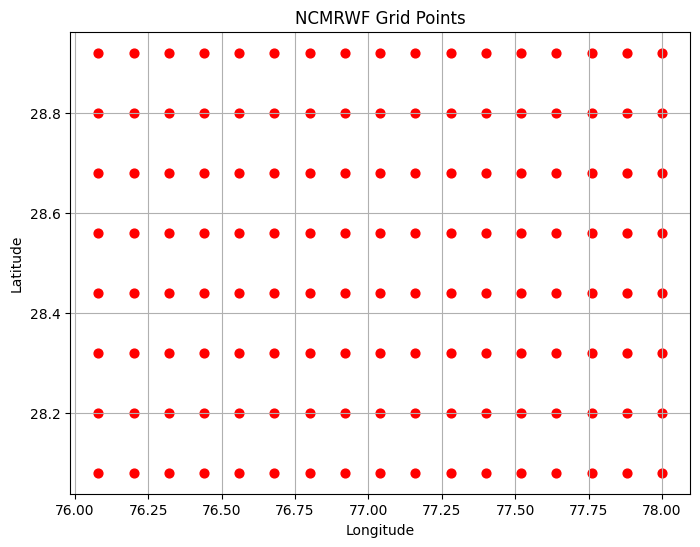

In [11]:
import numpy as np
import matplotlib.pyplot as plt

lon_grid, lat_grid = np.meshgrid(lon, lat)

plt.figure(figsize=(8,6))

plt.scatter(lon_grid, lat_grid, color="red", s=40)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NCMRWF Grid Points")

plt.grid(True)
plt.show()

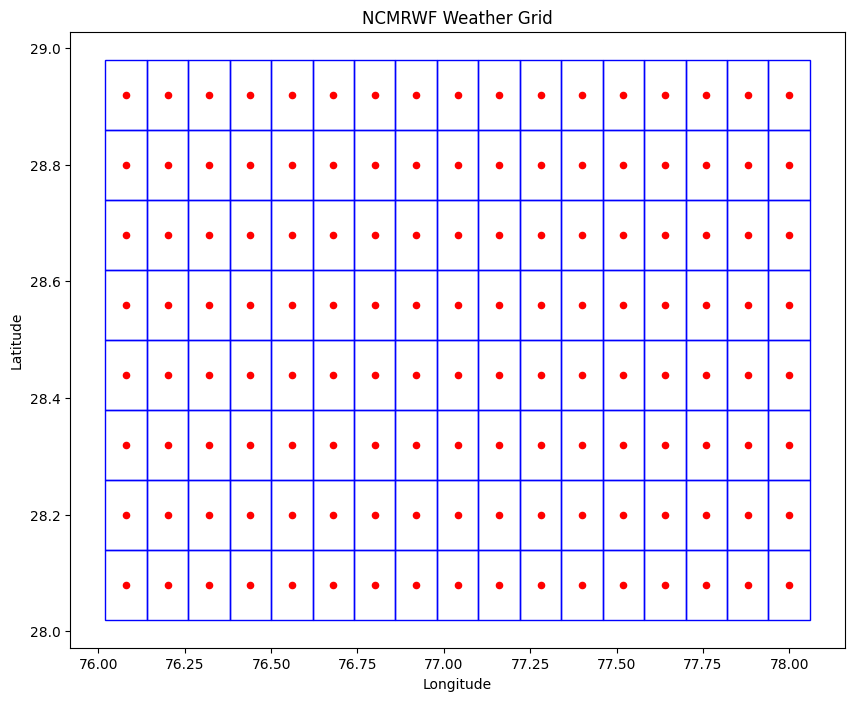

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# Create grid
lon_grid, lat_grid = np.meshgrid(lon, lat)

# Grid spacing
dlat = lat[1] - lat[0]
dlon = lon[1] - lon[0]

fig, ax = plt.subplots(figsize=(10, 8))

# Draw each grid cell
for x, y in zip(lon_grid.ravel(), lat_grid.ravel()):
    rect = Rectangle(
        (x - dlon/2, y - dlat/2),
        dlon,
        dlat,
        fill=False,
        edgecolor="blue",
        linewidth=1
    )
    ax.add_patch(rect)

# Draw grid centres
ax.scatter(lon_grid, lat_grid, color="red", s=20)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("NCMRWF Weather Grid")

plt.grid(False)
plt.show()

Overlay grids with actual delhi boundary

In [13]:
!pip install geopandas

In [14]:
#import delhi boundary
import geopandas as gpd

world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

india = world[world["name"] == "India"]

india.plot(figsize=(8,8))

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

we will be using osm

In [15]:
!pip install osmnx geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.3 MB/s eta 0:00:00


In [16]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

In [17]:
delhi = ox.geocode_to_gdf("National Capital Territory of Delhi, India")

print(delhi["display_name"])

0    Delhi, India
Name: display_name, dtype: object


When we used the delhi instead of NCT of delhi, it gave the boundary of new delhi

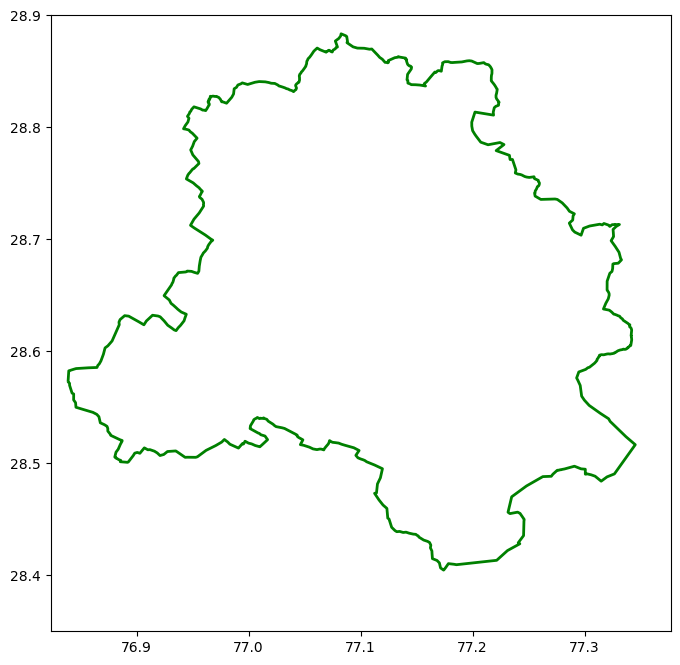

In [18]:
fig, ax = plt.subplots(figsize=(8,8))

delhi.boundary.plot(ax=ax, color="green", linewidth=2)

plt.axis("equal")
ax.set_xlim(76.8, 77.4)
ax.set_ylim(28.35, 28.9)
plt.show()

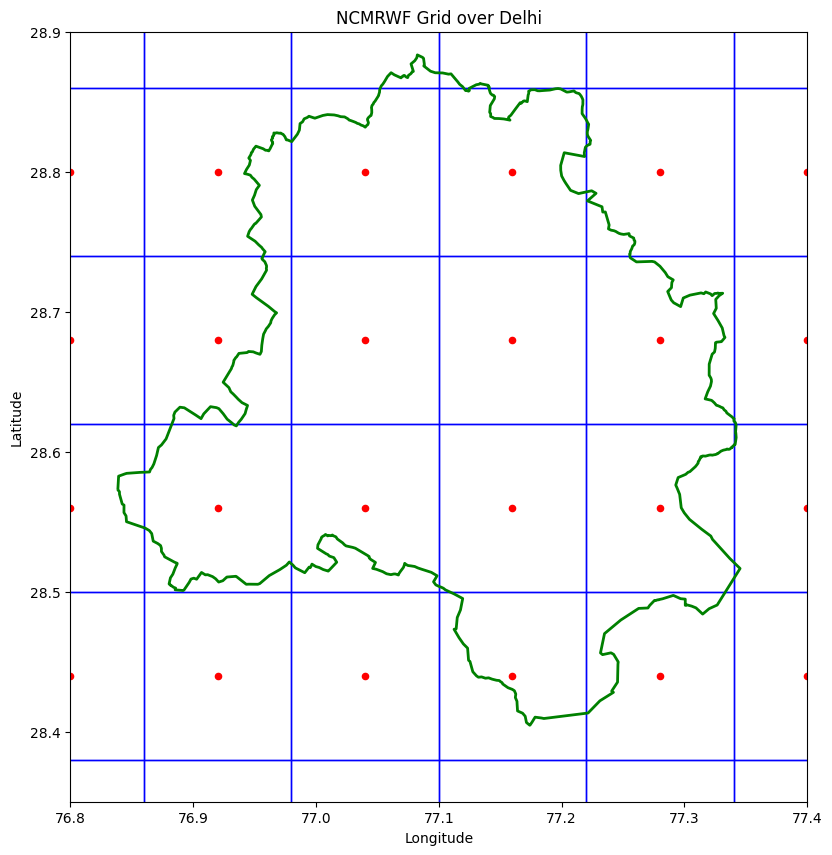

In [19]:
fig, ax = plt.subplots(figsize=(10,10))

# Delhi Boundary
delhi.boundary.plot(ax=ax,
                    color="green",
                    linewidth=2)

# Weather Cells
for x, y in zip(lon_grid.ravel(), lat_grid.ravel()):
    rect = Rectangle(
        (x-dlon/2, y-dlat/2),
        dlon,
        dlat,
        fill=False,
        edgecolor="blue",
        linewidth=1
    )
    ax.add_patch(rect)

# Grid Centres
ax.scatter(lon_grid,
           lat_grid,
           color="red",
           s=20)

ax.set_xlim(76.8,77.4)
ax.set_ylim(28.35,28.9)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("NCMRWF Grid over Delhi")

plt.show()

In [20]:
from shapely.geometry import Point
import geopandas as gpd

# Flatten the grid
lon_flat = lon_grid.ravel()
lat_flat = lat_grid.ravel()

# Create Point objects
points = [Point(x, y) for x, y in zip(lon_flat, lat_flat)]

# Create GeoDataFrame
grid_points = gpd.GeoDataFrame(
    geometry=points,
    crs="EPSG:4326"
)

grid_points.head()

,geometry
0,POINT (76.08 28.08)
1,POINT (76.2 28.08)
2,POINT (76.32 28.08)
3,POINT (76.44 28.08)
4,POINT (76.56 28.08)


In [21]:
print(delhi.crs)
print(grid_points.crs)

epsg:4326
EPSG:4326


In [22]:
inside = gpd.sjoin(
    grid_points,
    delhi,
    predicate="within",
    how="inner"
)

In [23]:
print("Total Weather Cells Downloaded :", len(grid_points))
print("Weather Cells Inside Delhi :", len(inside))

Total Weather Cells Downloaded : 136
Weather Cells Inside Delhi : 10


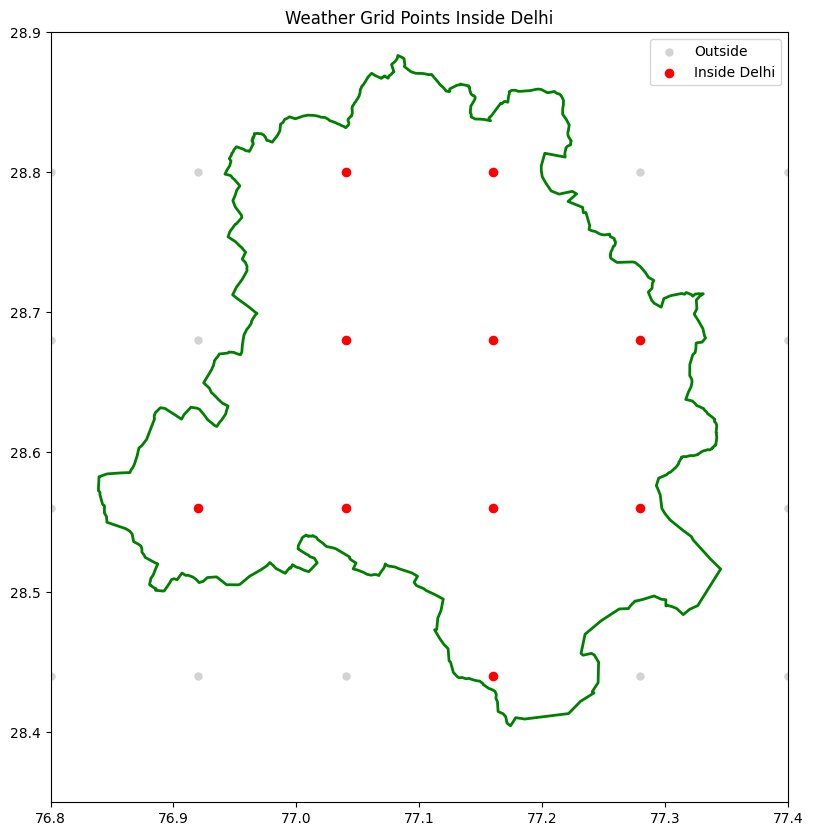

In [24]:
fig, ax = plt.subplots(figsize=(10,10))

# Delhi boundary
delhi.boundary.plot(ax=ax,
                    color="green",
                    linewidth=2)

# Outside Delhi
grid_points.plot(ax=ax,
                 color="lightgray",
                 markersize=25,
                 label="Outside")

# Inside Delhi
inside.plot(ax=ax,
            color="red",
            markersize=35,
            label="Inside Delhi")

plt.legend()
plt.title("Weather Grid Points Inside Delhi")

ax.set_xlim(76.8,77.4)
ax.set_ylim(28.35,28.9)

plt.show()

10 centres lies inside delhi

In [25]:
from shapely.geometry import box

# List to store polygons
polygons = []

for x, y in zip(lon_grid.ravel(), lat_grid.ravel()):
    poly = box(
        x - dlon/2,
        y - dlat/2,
        x + dlon/2,
        y + dlat/2
    )
    polygons.append(poly)

# Create GeoDataFrame
grid_cells = gpd.GeoDataFrame(
    geometry=polygons,
    crs="EPSG:4326"
)

grid_cells.head()

,geometry
0,"POLYGON ((76.14 28.02, 76.14 28.14, 76.02 28.1..."
1,"POLYGON ((76.26 28.02, 76.26 28.14, 76.14 28.1..."
2,"POLYGON ((76.38 28.02, 76.38 28.14, 76.26 28.1..."
3,"POLYGON ((76.5 28.02, 76.5 28.14, 76.38 28.14,..."
4,"POLYGON ((76.62 28.02, 76.62 28.14, 76.5 28.14..."


In [26]:
intersecting = gpd.overlay(
    grid_cells,
    delhi,
    how="intersection"
)

In [27]:
print("Total Weather Cells :", len(grid_cells))
print("Cells Intersecting Delhi :", len(intersecting))

Total Weather Cells : 136
Cells Intersecting Delhi : 19


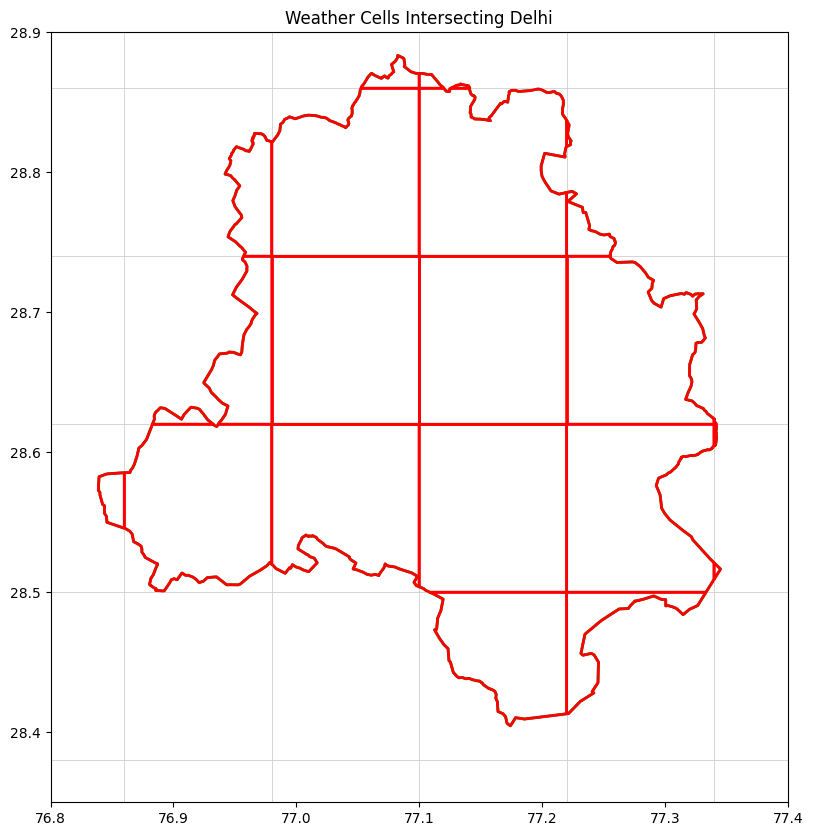

In [28]:
fig, ax = plt.subplots(figsize=(10,10))

# Delhi Boundary
delhi.boundary.plot(
    ax=ax,
    color="green",
    linewidth=2
)

# All weather cells
grid_cells.boundary.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.5
)

# Cells intersecting Delhi
intersecting.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2
)

ax.set_xlim(76.8,77.4)
ax.set_ylim(28.35,28.9)

plt.title("Weather Cells Intersecting Delhi")

plt.show()